# Step 7 — Time-Aware Model Evaluation

#### n this step, we will evaluate our machine learning models using chronological train, validation, and test data.

The main goal is to evaluate model performance without using future information to predict the past.

We will use:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Evaluation metrics:
- MAE
- RMSE
- R²


In [4]:

# Step 7.1: Import Required Libraries

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
# Step 7.2: Load Feature-Engineered Data

train = pd.read_csv("../data/processed/train_features.csv")

train["Date"] = pd.to_datetime(train["Date"])

print("Shape:", train.shape)
print("Date Range:", train["Date"].min(), "to", train["Date"].max())

Shape: (1017209, 29)
Date Range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


In [6]:
# Step 7.3: Define Features and Target

features = [
    "Store",
    "DayOfWeek",
    "Open",
    "Promo",
    "SchoolHoliday",
    "Year",
    "Month",
    "Day",
    "WeekOfYear",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "Promo2",
    "IsStateHoliday",
    "Lag_1_Sales",
    "Lag_7_Sales",
    "Lag_14_Sales",
    "Rolling_7_Sales",
    "Rolling_14_Sales",
    "Rolling_30_Sales"
]

target = "Sales"

print("Number of Features:", len(features))
print("Target:", target)

Number of Features: 20
Target: Sales


In [7]:
# Step 7.4: Chronological Train-Validation-Test Split

train_end = train["Date"].quantile(0.70)
valid_end = train["Date"].quantile(0.85)

train_data = train[train["Date"] <= train_end]
valid_data = train[
    (train["Date"] > train_end) &
    (train["Date"] <= valid_end)
]
test_data = train[train["Date"] > valid_end]

print("Train End:", train_end)
print("Validation End:", valid_end)

print("Training Data:", train_data.shape)
print("Validation Data:", valid_data.shape)
print("Test Data:", test_data.shape)

Train End: 2014-10-19 00:00:00
Validation End: 2015-03-17 00:00:00
Training Data: (712574, 29)
Validation Data: (152995, 29)
Test Data: (151640, 29)


In [8]:
# Step 7.5: Prepare Features and Target for Each Split

# Remove rows with missing feature values
train_data = train_data.dropna(subset=features)
valid_data = valid_data.dropna(subset=features)
test_data = test_data.dropna(subset=features)

# Training data
X_train = train_data[features]
y_train = train_data[target]

# Validation data
X_valid = valid_data[features]
y_valid = valid_data[target]

# Test data
X_test = test_data[features]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nMissing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_valid:", X_valid.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

X_train: (677354, 20)
y_train: (677354,)
X_valid: (152621, 20)
y_valid: (152621,)
X_test: (151232, 20)
y_test: (151232,)

Missing values in X_train: 0
Missing values in X_valid: 0
Missing values in X_test: 0


In [9]:
# Step 7.6: Encode Categorical Features

X_train = pd.get_dummies(
    X_train,
    columns=["StoreType", "Assortment"]
)

X_valid = pd.get_dummies(
    X_valid,
    columns=["StoreType", "Assortment"]
)

X_test = pd.get_dummies(
    X_test,
    columns=["StoreType", "Assortment"]
)

# Make sure all datasets have the same columns
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=False)
X_test = X_test.reindex(columns=X_train.columns, fill_value=False)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

print("\nSame columns:",
      list(X_train.columns) == list(X_valid.columns) == list(X_test.columns))

X_train: (677354, 25)
X_valid: (152621, 25)
X_test: (151232, 25)

Same columns: True


In [10]:
# Step 7.7: Train Baseline Models

linear_model = LinearRegression()

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

# Train models
linear_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

gradient_boosting_model.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


In [11]:
# Step 7.8: Make Predictions on Validation Data

linear_valid_pred = linear_model.predict(X_valid)

random_forest_valid_pred = random_forest_model.predict(X_valid)

gradient_boosting_valid_pred = gradient_boosting_model.predict(X_valid)

print("Validation predictions completed.")

print("Linear Regression predictions:", linear_valid_pred.shape)
print("Random Forest predictions:", random_forest_valid_pred.shape)
print("Gradient Boosting predictions:", gradient_boosting_valid_pred.shape)

Validation predictions completed.
Linear Regression predictions: (152621,)
Random Forest predictions: (152621,)
Gradient Boosting predictions: (152621,)


In [12]:
# Step 7.9: Calculate Validation Metrics

validation_results = []

models_and_predictions = [
    ("Linear Regression", linear_valid_pred),
    ("Random Forest", random_forest_valid_pred),
    ("Gradient Boosting", gradient_boosting_valid_pred)
]

for model_name, predictions in models_and_predictions:

    mae = mean_absolute_error(y_valid, predictions)
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    r2 = r2_score(y_valid, predictions)

    validation_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

validation_results = pd.DataFrame(validation_results)

print(validation_results)

               Model          MAE         RMSE        R2
0  Linear Regression  1074.900971  1526.604856  0.852886
1      Random Forest   597.368900  1043.956640  0.931203
2  Gradient Boosting   758.691292  1134.811968  0.918708


In [13]:
# Step 7.10: Make Predictions on Test Data

linear_test_pred = linear_model.predict(X_test)

random_forest_test_pred = random_forest_model.predict(X_test)

gradient_boosting_test_pred = gradient_boosting_model.predict(X_test)

print("Test predictions completed.")

print("Linear Regression predictions:", linear_test_pred.shape)
print("Random Forest predictions:", random_forest_test_pred.shape)
print("Gradient Boosting predictions:", gradient_boosting_test_pred.shape)

Test predictions completed.
Linear Regression predictions: (151232,)
Random Forest predictions: (151232,)
Gradient Boosting predictions: (151232,)


In [15]:
# Step 7.11: Calculate Test Metrics

test_results = []

models_and_predictions = [
    ("Linear Regression", linear_test_pred),
    ("Random Forest", random_forest_test_pred),
    ("Gradient Boosting", gradient_boosting_test_pred)
]

for model_name, predictions in models_and_predictions:

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    test_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

test_results = pd.DataFrame(test_results)

print(test_results)

               Model          MAE         RMSE        R2
0  Linear Regression  1009.328451  1468.975312  0.861737
1      Random Forest   514.200077   832.053242  0.955641
2  Gradient Boosting   655.592765   995.671446  0.936480


In [16]:
# Step 7.12: Compare Validation and Test Results

validation_results["Dataset"] = "Validation"
test_results["Dataset"] = "Test"

comparison_results = pd.concat(
    [validation_results, test_results],
    ignore_index=True
)

comparison_results = comparison_results[
    ["Dataset", "Model", "MAE", "RMSE", "R2"]
]

print(comparison_results)

      Dataset              Model          MAE         RMSE        R2
0  Validation  Linear Regression  1074.900971  1526.604856  0.852886
1  Validation      Random Forest   597.368900  1043.956640  0.931203
2  Validation  Gradient Boosting   758.691292  1134.811968  0.918708
3        Test  Linear Regression  1009.328451  1468.975312  0.861737
4        Test      Random Forest   514.200077   832.053242  0.955641
5        Test  Gradient Boosting   655.592765   995.671446  0.936480


In [17]:
# Step 7.13: Final Verification

print("===== STEP 7 FINAL VERIFICATION =====")

# 1. Chronological order
print("\n1. Chronological Split:")
print("Train:", train_data["Date"].min(), "to", train_data["Date"].max())
print("Validation:", valid_data["Date"].min(), "to", valid_data["Date"].max())
print("Test:", test_data["Date"].min(), "to", test_data["Date"].max())

# 2. Dataset sizes
print("\n2. Dataset Sizes:")
print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

# 3. Missing values
print("\n3. Missing Values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_valid.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

# 4. Feature consistency
print("\n4. Feature Consistency:")
print("Train vs Validation:", list(X_train.columns) == list(X_valid.columns))
print("Train vs Test:", list(X_train.columns) == list(X_test.columns))

# 5. Models
print("\n5. Models Evaluated:")
print(validation_results["Model"].tolist())

# 6. Final comparison
print("\n6. Validation and Test Results:")
print(comparison_results)

print("\n===== STEP 7 VERIFICATION COMPLETE =====")

===== STEP 7 FINAL VERIFICATION =====

1. Chronological Split:
Train: 2013-01-31 00:00:00 to 2014-10-19 00:00:00
Validation: 2014-10-20 00:00:00 to 2015-03-17 00:00:00
Test: 2015-03-18 00:00:00 to 2015-07-31 00:00:00

2. Dataset Sizes:
Train: (677354, 25)
Validation: (152621, 25)
Test: (151232, 25)

3. Missing Values:
Train: 0
Validation: 0
Test: 0

4. Feature Consistency:
Train vs Validation: True
Train vs Test: True

5. Models Evaluated:
['Linear Regression', 'Random Forest', 'Gradient Boosting']

6. Validation and Test Results:
      Dataset              Model          MAE         RMSE        R2
0  Validation  Linear Regression  1074.900971  1526.604856  0.852886
1  Validation      Random Forest   597.368900  1043.956640  0.931203
2  Validation  Gradient Boosting   758.691292  1134.811968  0.918708
3        Test  Linear Regression  1009.328451  1468.975312  0.861737
4        Test      Random Forest   514.200077   832.053242  0.955641
5        Test  Gradient Boosting   655.592765   9

In [18]:
# Step 7.14: Compare Actual vs Predicted Sales

prediction_check = pd.DataFrame({
    "Actual_Sales": y_test.values,
    "Predicted_Sales": random_forest_test_pred
})

print(prediction_check.head(20))

    Actual_Sales  Predicted_Sales
0           3858          5135.69
1           4748          4377.90
2           4057          4830.39
3           3909          4573.79
4              0             0.00
5           3565          3916.61
6           3547          3764.52
7           3531          3712.46
8           3932          3515.61
9           4005          3847.76
10          5208          4899.05
11             0             0.00
12          6714          6172.13
13          6206          6411.00
14          6816          5332.04
15          6574          5595.87
16             0             0.00
17          6709          5031.71
18             0             0.00
19             0             0.00


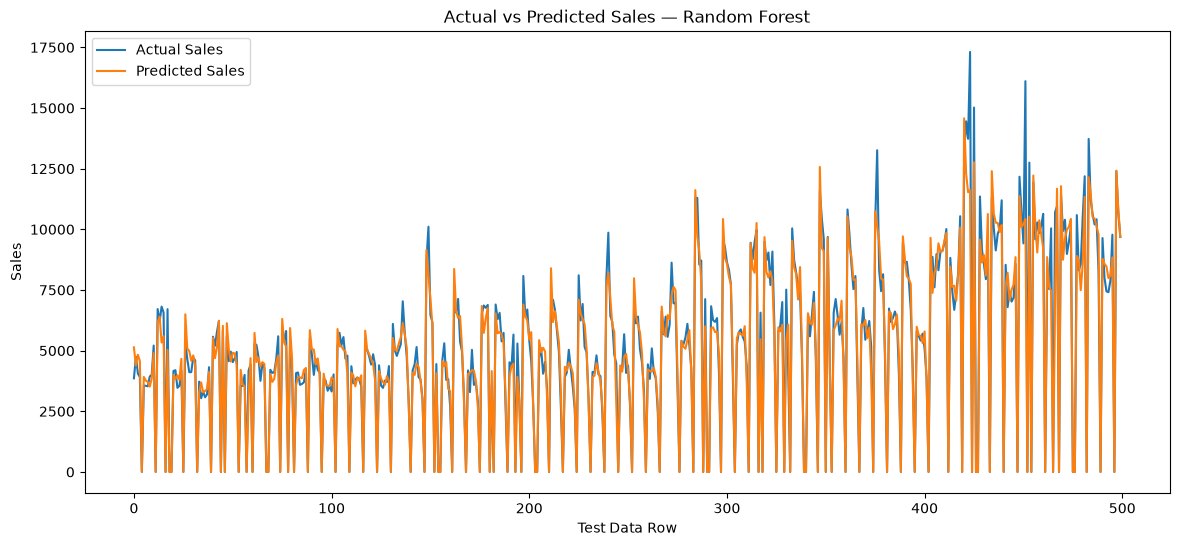

In [19]:
# Step 7.15: Actual vs Predicted Sales

import matplotlib.pyplot as plt

plot_data = prediction_check.head(500)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["Actual_Sales"].values,
    label="Actual Sales"
)

plt.plot(
    plot_data["Predicted_Sales"].values,
    label="Predicted Sales"
)

plt.xlabel("Test Data Row")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales — Random Forest")
plt.legend()
plt.show()

In [ ]:
S